# Confusion matrices

Based on `si_confusion_matrix.py`: the same Seaborn heatmap and `tight_layout()` workflow. All input matrices use alphabetical row and column order: Anger, Disgust, Fear, Happiness, Neutral, Sadness, Surprise. Each matrix is defined and plotted in its own cell. Model names belong in the LaTeX subcaptions; plots have no titles or colorbars.

Cells show counts and row percentages. Colors use a shared 0–100% scale. Image and Multimodal contain 756 view predictions each; FEA contains 378 reenactment predictions. Counts come from `6_discussion/multimodal-analysis/dynamic_error_analysis.ipynb` in `2026-09-21-4-emohevrdb-dfer.zip`.

Change the function defaults below, then rerun the matrix cells and export cell. Requires NumPy, Seaborn, and Matplotlib.

In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path


In [2]:
EXPORT_DIR = Path("figures/confusion_matrices")  # Output directory, relative to the notebook's working directory.
EXPORT_FORMATS = ("pdf", "png")  # File formats to export; optionally add "svg".
EXPORT_DPI = 400  # Resolution in dots per inch for PNG and rasterized elements.
EXPORT_PAD_INCHES = 0.02  # Extra margin around the tightly cropped export, in inches.
SAVE_FIGURES = True  # If True, save the figures; if False, only display them.


def export_figure(fig, stem):
    """Export to the configured directory; reruns replace files with the same name."""
    if not SAVE_FIGURES:
        return
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    with plt.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"}):
        for extension in EXPORT_FORMATS:
            path = EXPORT_DIR / f"{stem}.{extension}"
            fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", pad_inches=EXPORT_PAD_INCHES)
            print(path)


In [3]:
def plot_confusion_matrix(
    cm,
    figsize=(7, 7),            # Figure width and height in inches
    cmap='Blues',              # Colormap; all matrices use the same 0–100% scale
    color_max=100,             # Color-scale maximum in percent; None uses this plot's maximum
    end_color="#04092e",       # Custom upper-end color, e.g. '#060a26'; None keeps the original colormap
    count_fontsize=17,         # Count font size in points
    count_weight='bold',       # Count font weight: 'normal' or 'bold'
    percent_fontsize=11,       # Percentage font size in points
    percent_weight='normal',   # Percentage font weight: 'normal' or 'bold'
    percent_decimals=2,        # Decimal places in percentages
    count_y=0.4,       # Vertical count position within each cell: 0 = top, 1 = bottom
    percent_y=0.7,    # Vertical percentage position within each cell: 0 = top, 1 = bottom
    label_fontsize=12,         # Axis title font size in points
    label_weight='bold',       # Axis title font weight: 'normal' or 'bold'
    tick_fontsize=11,          # Class-name font size in points
    linewidths=1,             # Cell border width in points; 0 removes borders
    linecolor='white',        # Cell border color
    xlabel='Predicted Class', # x-axis title; use '' to hide it
    ylabel='True Class',      # y-axis title; use '' to hide it
):
    # Rows and columns are already in alphabetical class order.
    labels = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
    cm = np.array(cm)
    percentages = 100 * cm / cm.sum(axis=1, keepdims=True)

    vmax = percentages.max() if color_max is None else color_max
    if vmax <= 0 or vmax < percentages.max():
        raise ValueError("color_max must cover every cell percentage.")

    if end_color is not None:
        base_cmap = plt.get_cmap(cmap)
        stops = [(x * 0.88, base_cmap(x)) for x in np.linspace(0, 1, 12)]
        cmap = LinearSegmentedColormap.from_list(
            "extended_cmap", stops + [(1, end_color)]
        )

    fig = plt.figure(figsize=figsize)
    ax = sns.heatmap(
        percentages,
        annot=cm,
        fmt='d',
        cmap=cmap,
        vmin=0, vmax=vmax,
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        linewidths=linewidths, linecolor=linecolor,
        annot_kws={'size': count_fontsize, 'weight': count_weight},
    )

    # Choose black or white based on the actual cell background.
    heatmap = ax.collections[0]
    for text, percent in zip(list(ax.texts), percentages.flat):
        x, y = text.get_position()
        row_top = y - 0.5  # Seaborn initially places counts at the cell center.
        
        # rgb = np.array(heatmap.cmap(heatmap.norm(percent))[:3])
        # linear = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
        # color = "white" if linear @ [0.2126, 0.7152, 0.0722] < 0.179 else "black"
        color = "white" if percent > 50 else "black"
        
        text.set_y(row_top + count_y)
        text.set_va("center")
        text.set_color(color)
        ax.text(x, row_top + percent_y, f'{percent:.{percent_decimals}f}%',
                ha='center', va='center', color=color,
                fontsize=percent_fontsize, fontweight=percent_weight)

    plt.xlabel(xlabel, fontsize=label_fontsize, fontweight=label_weight)
    plt.ylabel(ylabel, fontsize=label_fontsize, fontweight=label_weight)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.tight_layout()
    return fig

## Human-rater annotation results

Confusion matrix between prompted expression categories (rows) and categories assigned by human raters (columns).

figures/confusion_matrices/human_rater.pdf
figures/confusion_matrices/human_rater.png


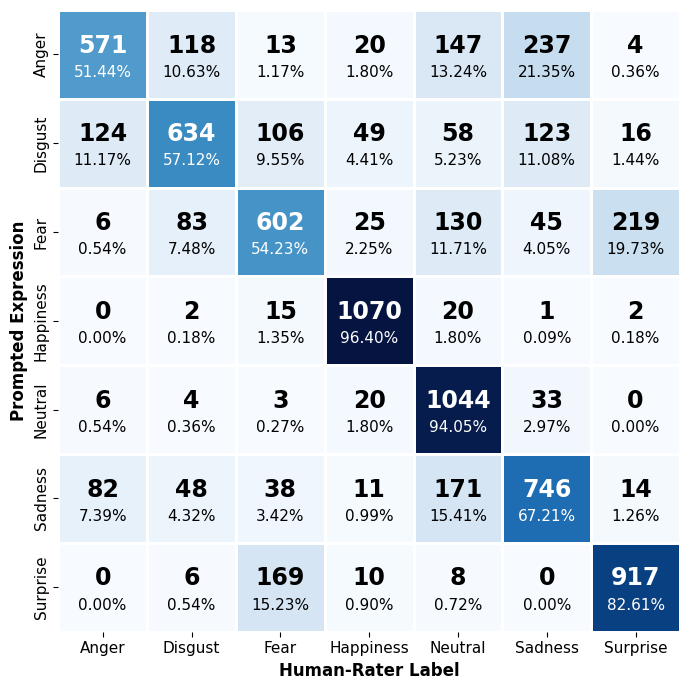

In [4]:
# Human-rater annotations
# Row and column order: Anger, Disgust, Fear, Happiness, Neutral, Sadness, Surprise.
human_rater_counts = [
    [ 571,  118,   13,   20,  147,  237,    4],
    [ 124,  634,  106,   49,   58,  123,   16],
    [   6,   83,  602,   25,  130,   45,  219],
    [   0,    2,   15, 1070,   20,    1,    2],
    [   6,    4,    3,   20, 1044,   33,    0],
    [  82,   48,   38,   11,  171,  746,   14],
    [   0,    6,  169,   10,    8,    0,  917],
]

fig_hr = plot_confusion_matrix(
    human_rater_counts,
    xlabel="Human-Rater Label",
    ylabel="Prompted Expression",
)
export_figure(fig_hr, "human_rater")
plt.show()
plt.close(fig_hr)

figures/confusion_matrices/filtered_human_rater.pdf
figures/confusion_matrices/filtered_human_rater.png


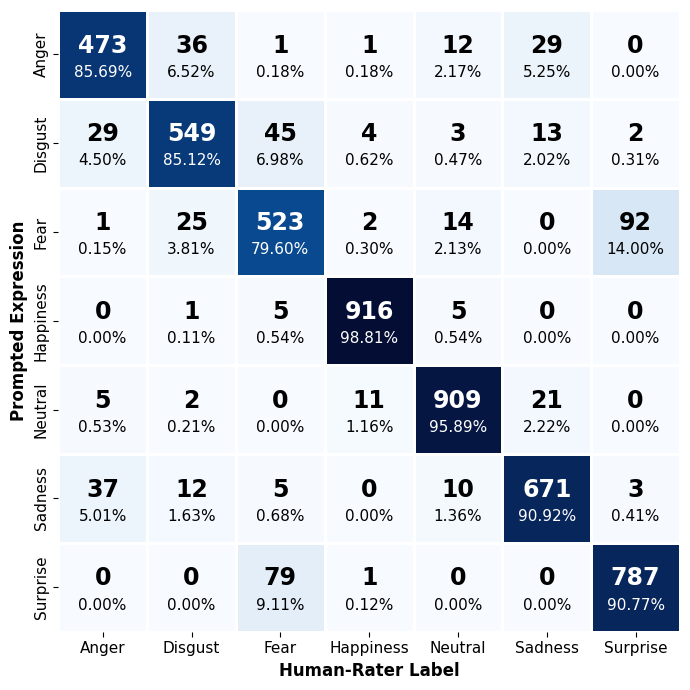

In [5]:
# After majority-vote filter
filtered_human_rater_counts = [
    [473, 36,  1,   1,  12,  29,  0],
    [ 29, 549, 45,  4,   3,  13,  2],
    [  1, 25, 523,  2,  14,   0, 92],
    [  0,  1,  5, 916,   5,   0,  0],
    [  5,  2,  0,  11, 909,  21,  0],
    [ 37, 12,  5,   0,  10, 671,  3],
    [  0,  0, 79,   1,   0,   0, 787],
]

fig_fhr = plot_confusion_matrix(
    filtered_human_rater_counts,
    xlabel="Human-Rater Label",
    ylabel="Prompted Expression",
)
export_figure(fig_fhr, "filtered_human_rater")
plt.show()
plt.close(fig_hr)

## Static matrices

Row and column order: Anger, Disgust, Fear, Happiness, Neutral, Sadness, Surprise.

figures/confusion_matrices/si.pdf
figures/confusion_matrices/si.png


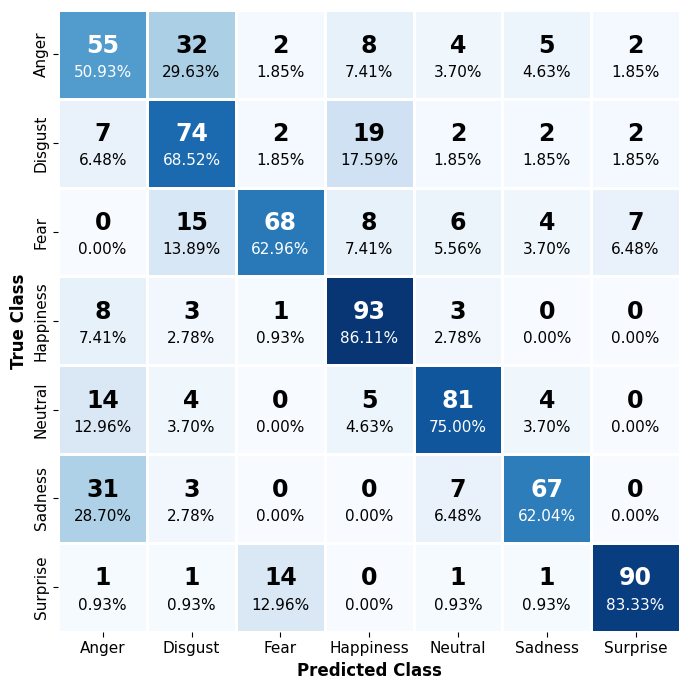

In [6]:
# Static Image
static_image_counts = [
    [55, 32,  2,  8,  4,  5,  2],
    [ 7, 74,  2, 19,  2,  2,  2],
    [ 0, 15, 68,  8,  6,  4,  7],
    [ 8,  3,  1, 93,  3,  0,  0],
    [14,  4,  0,  5, 81,  4,  0],
    [31,  3,  0,  0,  7, 67,  0],
    [ 1,  1, 14,  0,  1,  1, 90],
]

fig_si = plot_confusion_matrix(static_image_counts)
export_figure(fig_si, "si")
plt.show()
plt.close(fig_si)

figures/confusion_matrices/sfea.pdf
figures/confusion_matrices/sfea.png


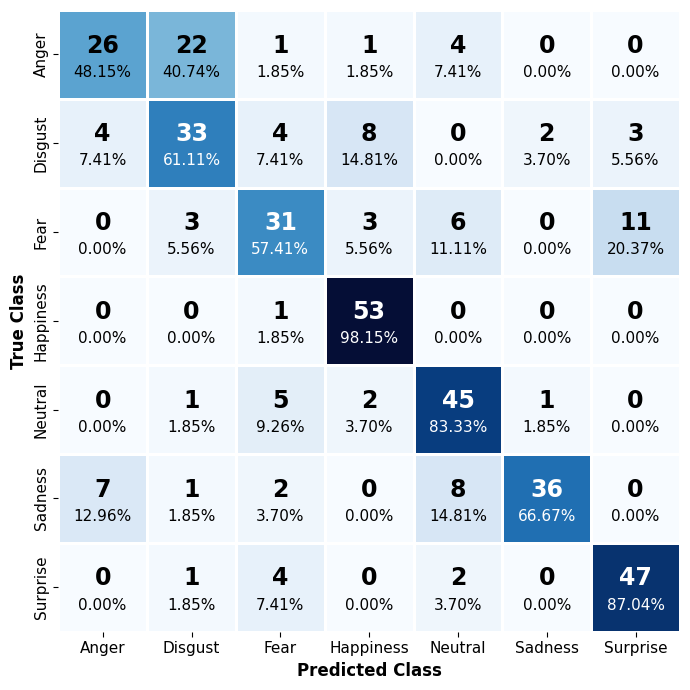

In [7]:
# Static FEA
static_fea_counts = [
    [26, 22,  1,  1,  4,  0,  0],
    [ 4, 33,  4,  8,  0,  2,  3],
    [ 0,  3, 31,  3,  6,  0, 11],
    [ 0,  0,  1, 53,  0,  0,  0],
    [ 0,  1,  5,  2, 45,  1,  0],
    [ 7,  1,  2,  0,  8, 36,  0],
    [ 0,  1,  4,  0,  2,  0, 47],
]

fig_sfea = plot_confusion_matrix(static_fea_counts)
export_figure(fig_sfea, "sfea")
plt.show()
plt.close(fig_sfea)

figures/confusion_matrices/smul.pdf
figures/confusion_matrices/smul.png


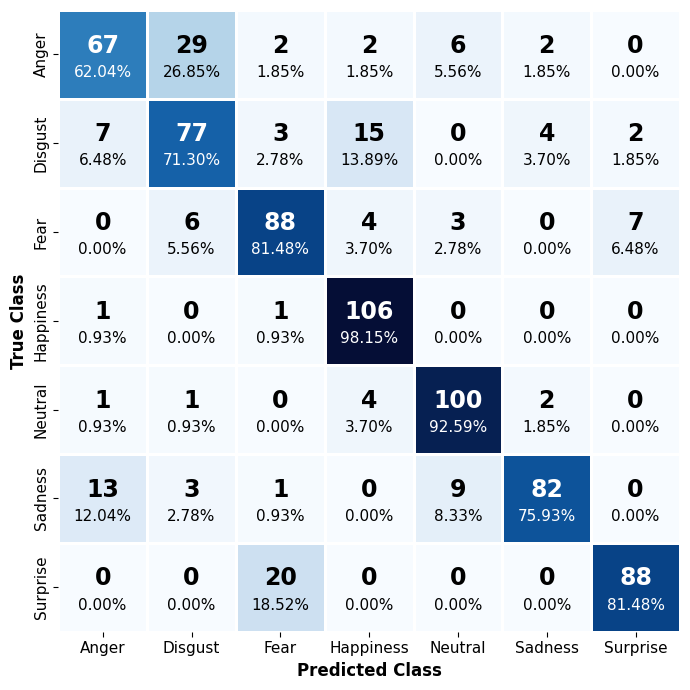

In [8]:
# Static Multimodal
static_multimodal_counts = [
    [ 67,  29,   2,   2,   6,   2,   0],
    [  7,  77,   3,  15,   0,   4,   2],
    [  0,   6,  88,   4,   3,   0,   7],
    [  1,   0,   1, 106,   0,   0,   0],
    [  1,   1,   0,   4, 100,   2,   0],
    [ 13,   3,   1,   0,   9,  82,   0],
    [  0,   0,  20,   0,   0,   0,  88],
]

fig_smul = plot_confusion_matrix(static_multimodal_counts)
export_figure(fig_smul, "smul")
plt.show()
plt.close(fig_smul)

## Dynamic matrices

Row and column order: Anger, Disgust, Fear, Happiness, Neutral, Sadness, Surprise.

figures/confusion_matrices/di.pdf
figures/confusion_matrices/di.png


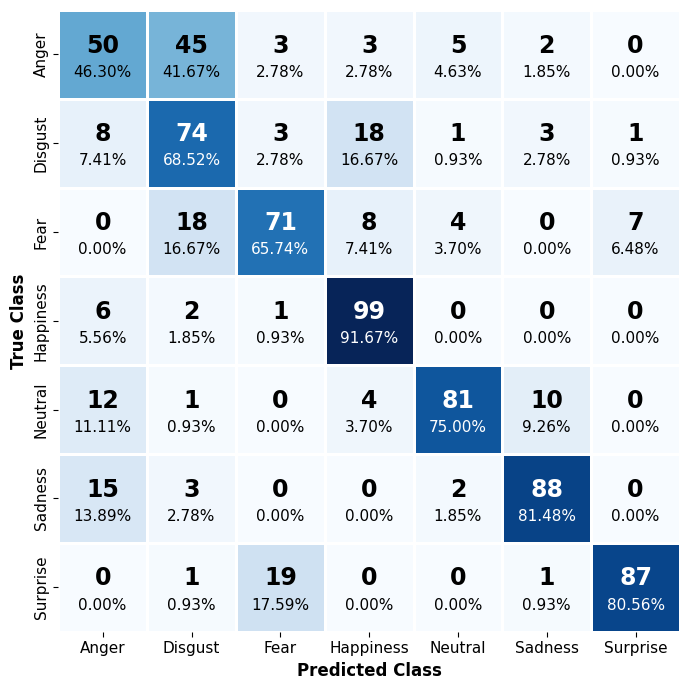

In [9]:
# Dynamic Image
dynamic_image_counts = [
    [50, 45,  3,  3,  5,  2,  0],
    [ 8, 74,  3, 18,  1,  3,  1],
    [ 0, 18, 71,  8,  4,  0,  7],
    [ 6,  2,  1, 99,  0,  0,  0],
    [12,  1,  0,  4, 81, 10,  0],
    [15,  3,  0,  0,  2, 88,  0],
    [ 0,  1, 19,  0,  0,  1, 87],
]

fig_di = plot_confusion_matrix(dynamic_image_counts)
export_figure(fig_di, "di")
plt.show()
plt.close(fig_di)

figures/confusion_matrices/dfea.pdf
figures/confusion_matrices/dfea.png


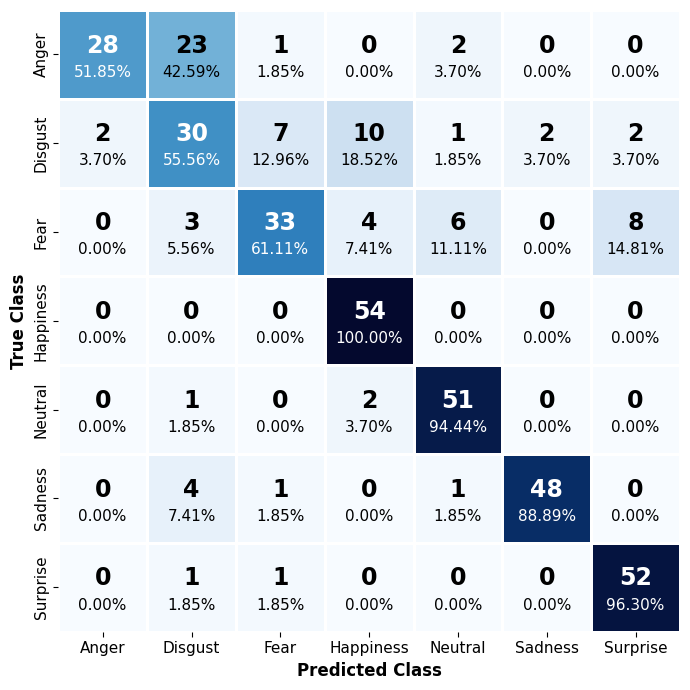

In [10]:
# Dynamic FEA
dynamic_fea_counts = [
    [28, 23,  1,  0,  2,  0,  0],
    [ 2, 30,  7, 10,  1,  2,  2],
    [ 0,  3, 33,  4,  6,  0,  8],
    [ 0,  0,  0, 54,  0,  0,  0],
    [ 0,  1,  0,  2, 51,  0,  0],
    [ 0,  4,  1,  0,  1, 48,  0],
    [ 0,  1,  1,  0,  0,  0, 52],
]

fig_dfea = plot_confusion_matrix(dynamic_fea_counts)
export_figure(fig_dfea, "dfea")
plt.show()
plt.close(fig_dfea)

figures/confusion_matrices/dmul.pdf
figures/confusion_matrices/dmul.png


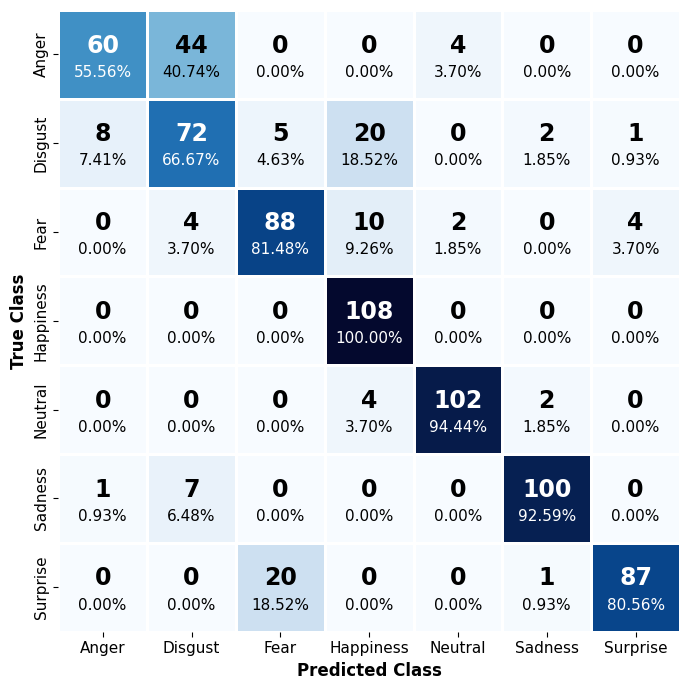

In [11]:
# Dynamic Multimodal
dynamic_multimodal_counts = [
    [ 60,  44,   0,   0,   4,   0,   0],
    [  8,  72,   5,  20,   0,   2,   1],
    [  0,   4,  88,  10,   2,   0,   4],
    [  0,   0,   0, 108,   0,   0,   0],
    [  0,   0,   0,   4, 102,   2,   0],
    [  1,   7,   0,   0,   0, 100,   0],
    [  0,   0,  20,   0,   0,   1,  87],
]

fig_dmul = plot_confusion_matrix(dynamic_multimodal_counts)
export_figure(fig_dmul, "dmul")
plt.show()
plt.close(fig_dmul)